## Exploratory Data Analysis

### 1. Project Objective

The purpose of this notebook is to explore the characteristics of the cleaned dataset before conducting business-focused analysis.

This notebook focuses on:

- Understanding variable distributions
- Identifying potential outliers
- Examining relationships between variables
- Recording initial observations

### 2. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.loader import load_clean_data
from src.visualization import plot_frequency_distribution


### 3. Load Clean Dataset

In [2]:
df = load_clean_data("../data/processed/superstore_clean.csv")

df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Weekday,Shipping Days,Profit Margin
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2013,11,November,4,Saturday,3,0.1600
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2013,11,November,4,Saturday,3,0.3000
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2013,6,June,2,Thursday,4,0.4700
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2012,10,October,4,Thursday,7,-0.4000
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2012,10,October,4,Thursday,7,0.1125


### 4. Numerical Variables

#### 4.1 Distribution

##### Sales

<Axes: xlabel='Sales', ylabel='Count'>

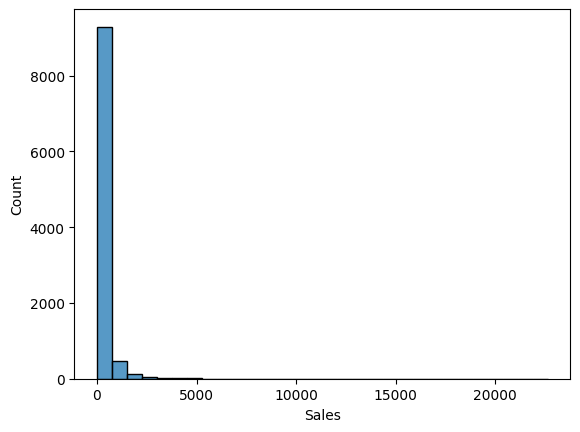

In [3]:
sns.histplot(df["Sales"], bins=30)

Sales is highly right-skewed.
Most orders have relatively small sales values.

##### Profit

<Axes: xlabel='Profit', ylabel='Count'>

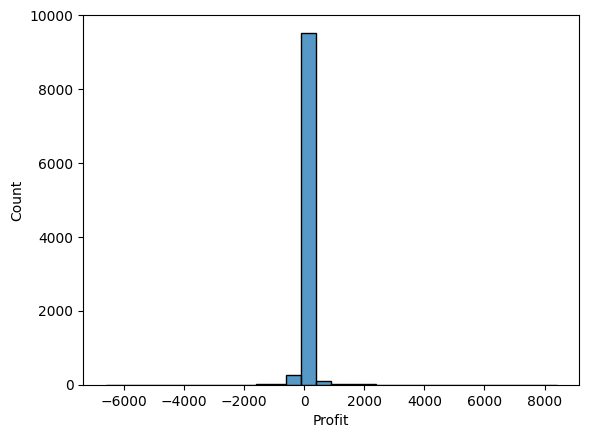

In [4]:
sns.histplot(df["Profit"], bins=30)

Profit contains both positive and negtive values.

##### Discount

<Axes: xlabel='Discount', ylabel='Count'>

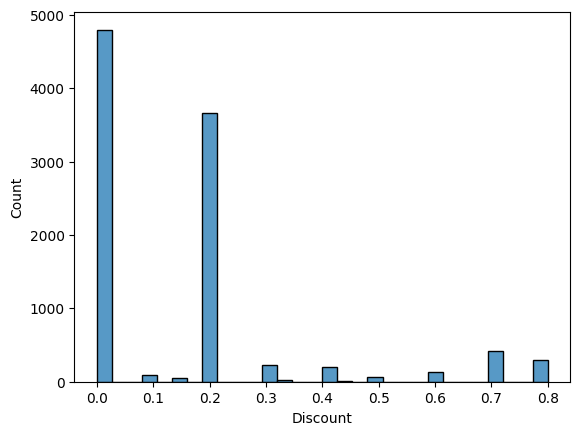

In [5]:
sns.histplot(df["Discount"], bins=30)

Discounts are concentrated on 0 and 0.2.

##### Quantity

<Axes: xlabel='Quantity', ylabel='Count'>

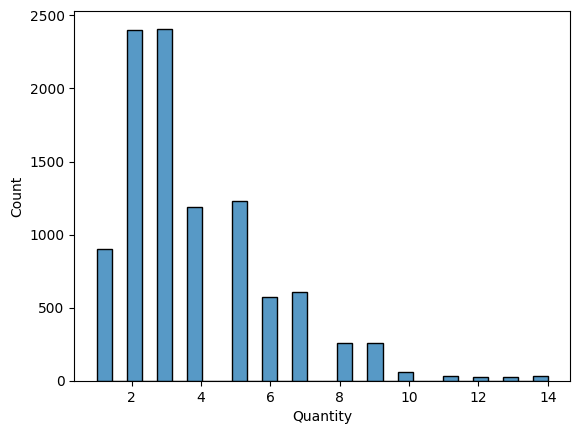

In [6]:
sns.histplot(df["Quantity"], bins=30)

An order typically contains 2 or 3 items.

##### Shipping Days

<Axes: xlabel='Shipping Days', ylabel='Count'>

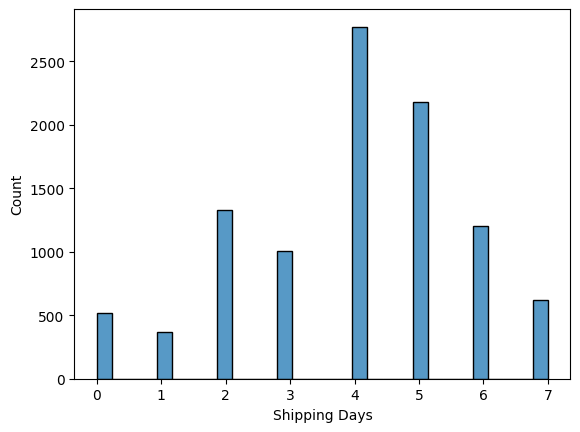

In [7]:
sns.histplot(df["Shipping Days"], bins=30)

The shipping days are mainly 4 or 5.

##### Profit Margin

<Axes: xlabel='Profit Margin', ylabel='Count'>

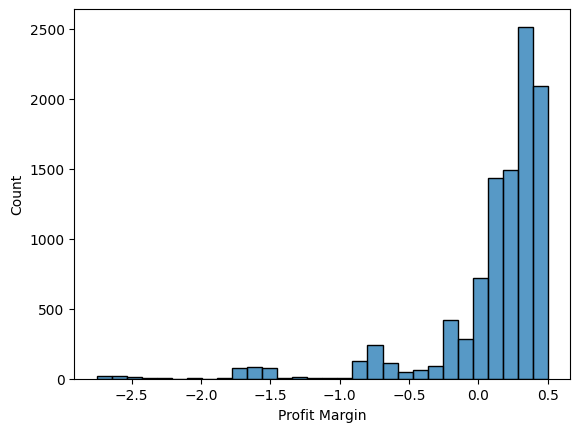

In [8]:
sns.histplot(df["Profit Margin"], bins=30)

There are particularly large negative profits.

#### 4.2 Summary Statistics

In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.0,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order Date,9994,2013-04-30 19:20:02.401441024,2011-01-04 00:00:00,2012-05-23 00:00:00,2013-06-27 00:00:00,2014-05-15 00:00:00,2014-12-31 00:00:00,NaN
Ship Date,9994,2013-05-04 18:20:49.229537792,2011-01-08 00:00:00,2012-05-27 00:00:00,2013-06-30 00:00:00,2014-05-19 00:00:00,2015-01-06 00:00:00,NaN
Sales,9994.0,229.858001,0.444,17.28,54.49,209.94,22638.48,623.245101
Quantity,9994.0,3.789574,1.0,2.0,3.0,5.0,14.0,2.22511
Discount,9994.0,0.156203,0.0,0.0,0.2,0.2,0.8,0.206452
Profit,9994.0,28.656896,-6599.978,1.72875,8.6665,29.364,8399.976,234.260108
Year,9994.0,2012.722934,2011.0,2012.0,2013.0,2014.0,2014.0,1.124039
Month,9994.0,7.814589,1.0,5.0,9.0,11.0,12.0,3.286047
Quarter,9994.0,2.88413,1.0,2.0,3.0,4.0,4.0,1.056771


#### 4.3 Outlier Detection

##### Sales

<Axes: xlabel='Sales'>

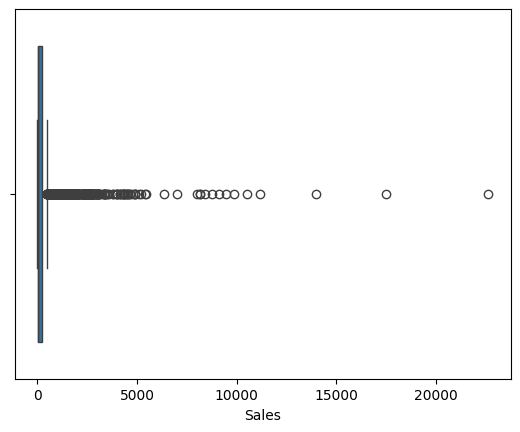

In [10]:
sns.boxplot(x=df["Sales"])

Sales contains several extreme values.

##### Profit

<Axes: xlabel='Profit'>

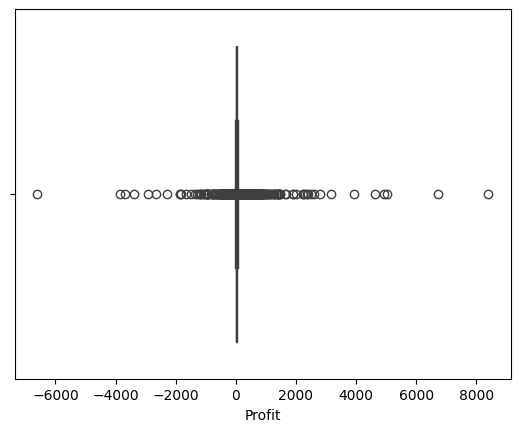

In [11]:
sns.boxplot(x=df["Profit"])

##### Quantity

<Axes: xlabel='Quantity'>

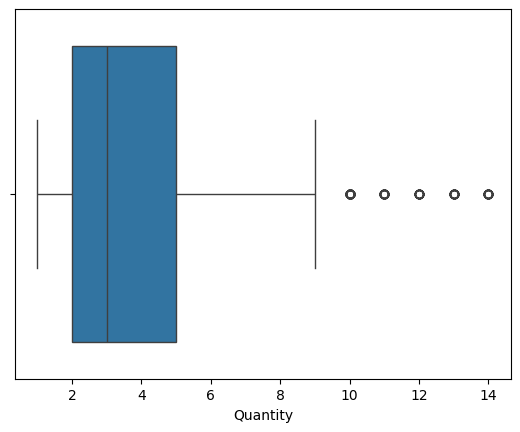

In [12]:
sns.boxplot(x=df["Quantity"])

### 5. Categorical Variables

#### 5.1 Frequency Distribution

##### Segment

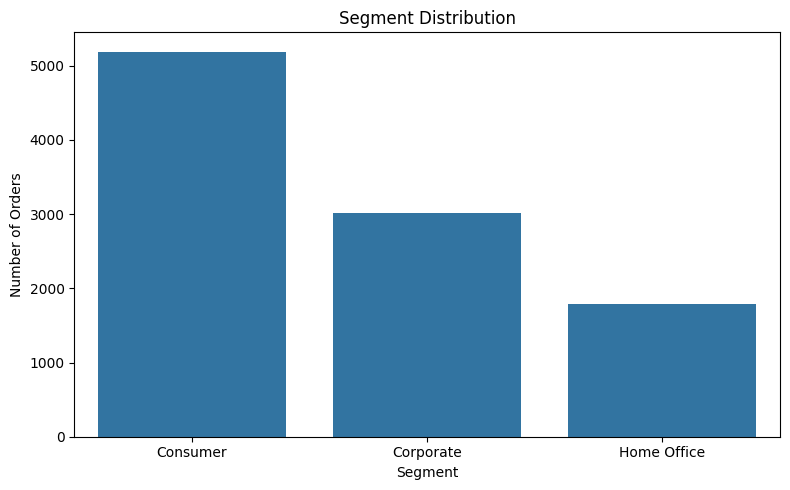

,Segment,Count,Percentage
0,Consumer,5191,51.94
1,Corporate,3020,30.22
2,Home Office,1783,17.84


In [13]:
segment_summary = plot_frequency_distribution(
    df,
    "Segment"
)

segment_summary

- Consumer is the largest customer segment.<br>
- Home Office has the fewest orders.

##### Category

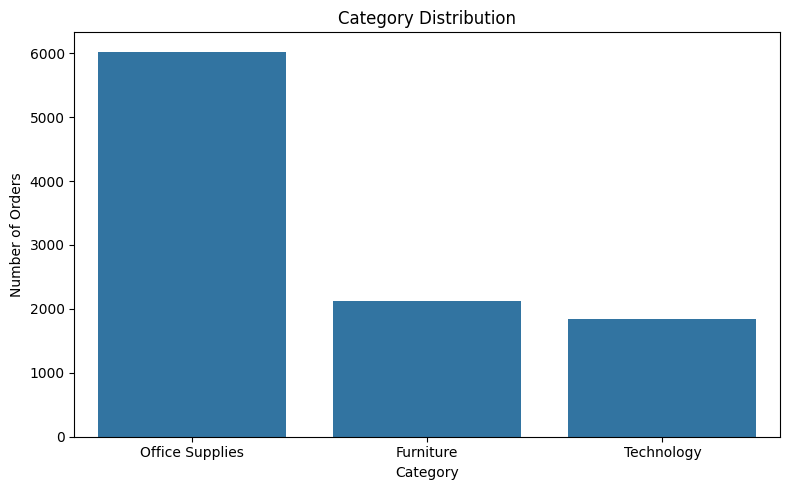

,Category,Count,Percentage
0,Office Supplies,6026,60.30
1,Furniture,2121,21.22
2,Technology,1847,18.48


In [14]:
category_summary = plot_frequency_distribution(
    df,
    "Category"
)

category_summary

Office Supplies appears most frequently, while Technology has the fewest order records.

##### Sub-Category

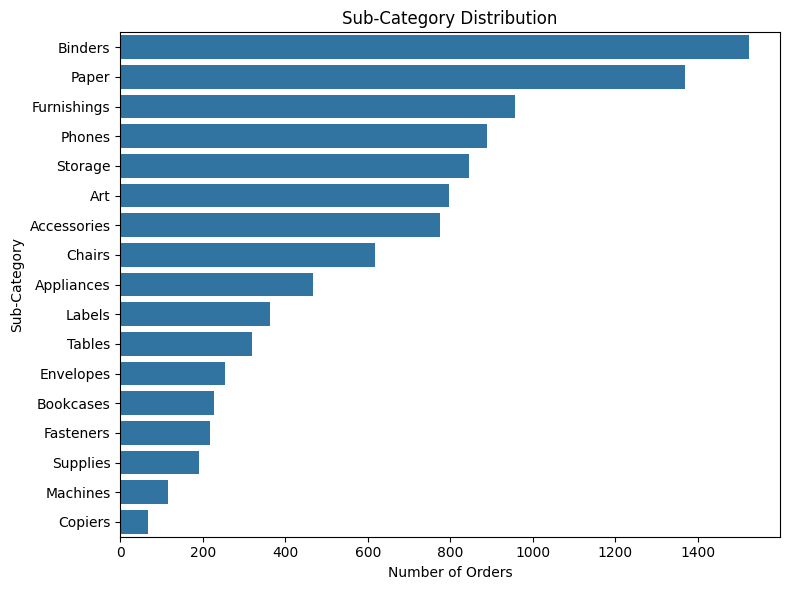

,Sub-Category,Count,Percentage
0,Binders,1523,15.24
1,Paper,1370,13.71
2,Furnishings,957,9.58
3,Phones,889,8.90
4,Storage,846,8.47
5,Art,796,7.96
6,Accessories,775,7.75
7,Chairs,617,6.17
8,Appliances,466,4.66
9,Labels,364,3.64


In [15]:
subcategory_summary = plot_frequency_distribution(
    df,
    "Sub-Category",
    figsize=(8, 6),
    horizontal=True
)

subcategory_summary

Several sub-categories contain substantially more records than others.

##### Region

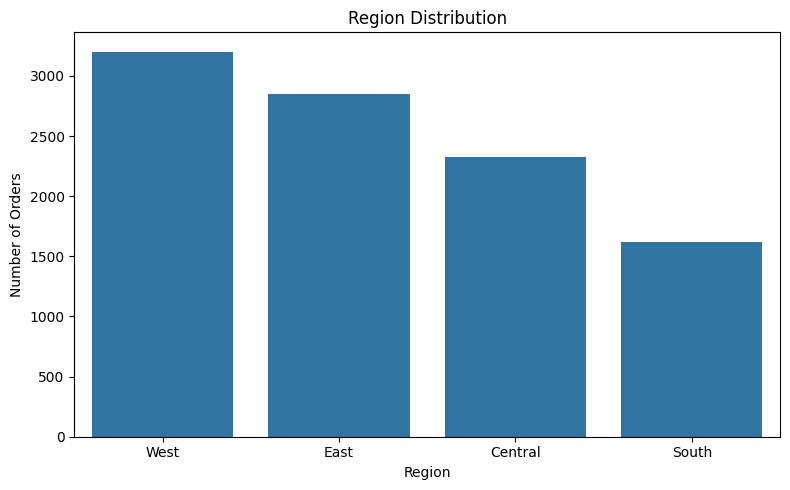

,Region,Count,Percentage
0,West,3203,32.05
1,East,2848,28.50
2,Central,2323,23.24
3,South,1620,16.21


In [16]:
region_summary = plot_frequency_distribution(
    df,
    "Region"
)

region_summary

West contains the largest number of orders.

##### Ship Mode

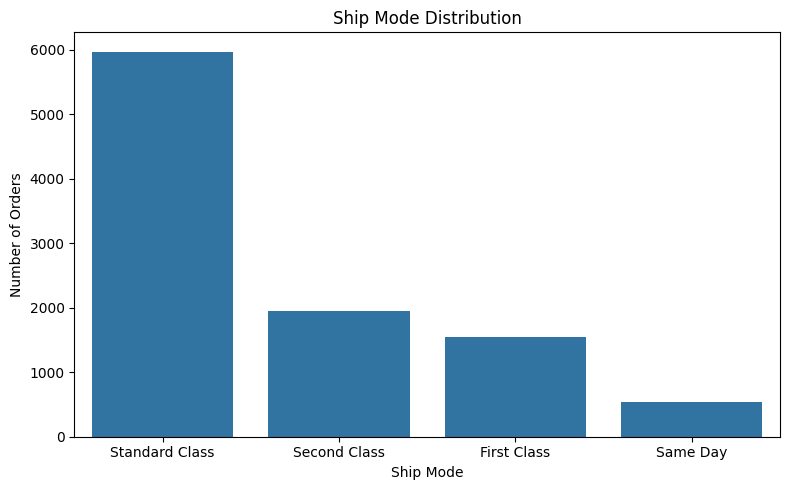

,Ship Mode,Count,Percentage
0,Standard Class,5968,59.72
1,Second Class,1945,19.46
2,First Class,1538,15.39
3,Same Day,543,5.43


In [17]:
ship_mode_summary = plot_frequency_distribution(
    df,
    "Ship Mode"
)

ship_mode_summary

Standard Class is the most commonly used shipping method.

#### 5.2 Cardinality

In [18]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

categorical_columns

['Order ID',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Month Name',
 'Weekday']

In [19]:
cardinality = pd.DataFrame({
    "Column": categorical_columns,
    "Unique Values": [df[col].nunique() for col in categorical_columns]
})

cardinality = cardinality.sort_values(
    by="Unique Values",
    ascending=False
).reset_index(drop=True)

cardinality

,Column,Unique Values
0,Order ID,5009
1,Product ID,1862
2,Product Name,1841
3,Customer ID,793
4,Customer Name,793
5,City,531
6,State,49
7,Sub-Category,17
8,Month Name,12
9,Weekday,7


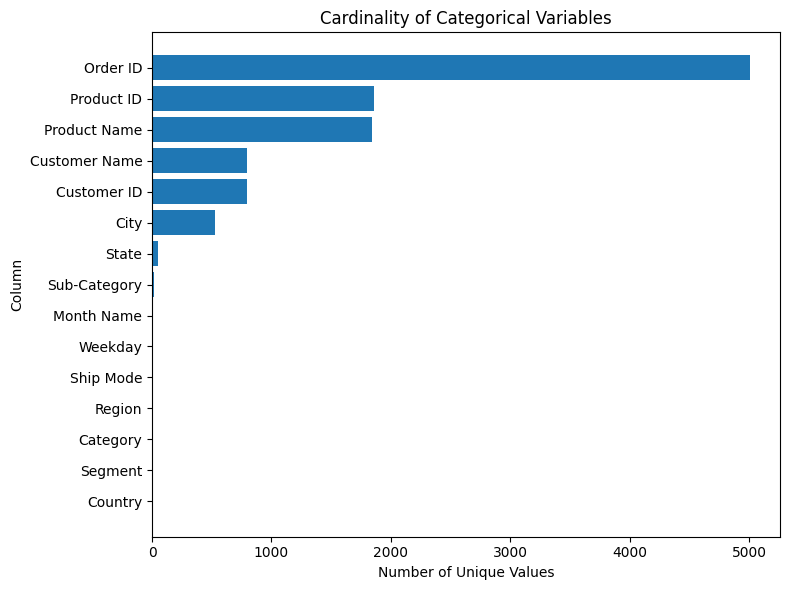

In [20]:
cardinality_sorted = cardinality.sort_values("Unique Values")

plt.figure(figsize=(8, 6))
plt.barh(
    cardinality_sorted["Column"],
    cardinality_sorted["Unique Values"]
)
plt.title("Cardinality of Categorical Variables")
plt.xlabel("Number of Unique Values")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

- Product-related fields (`Product ID` and `Product Name`) have high cardinality, indicating a wide variety of products.
- `Customer ID` also has high cardinality, suggesting a large customer base suitable for customer-level analysis.
- Variables such as `Category`, `Segment`, and `Region` have low cardinality and are well suited for grouped comparisons in later business analysis.
- `Country` contains only one unique value and is unlikely to provide analytical value in this dataset.

### 6. Relationships Between Variables

####  6.1 Correlation Matrix

<Axes: >

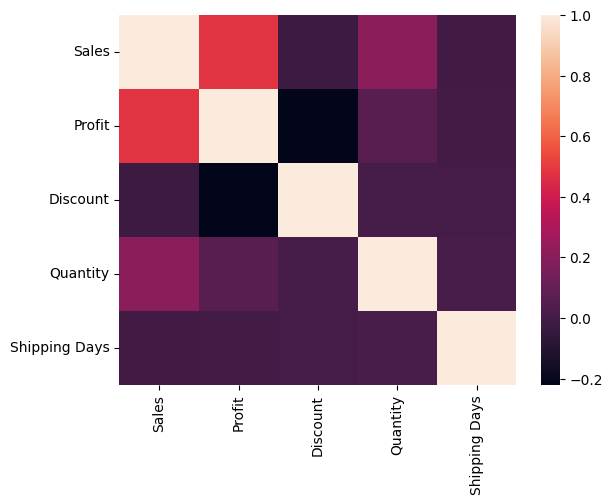

In [21]:
corr = df[
[
"Sales",
"Profit",
"Discount",
"Quantity",
"Shipping Days"
]
].corr()

sns.heatmap(corr)

Discount shows a moderate negative correlation with Profit.

####  6.2 Pairwise Relationships

##### Sales vs Profit

<Axes: xlabel='Sales', ylabel='Profit'>

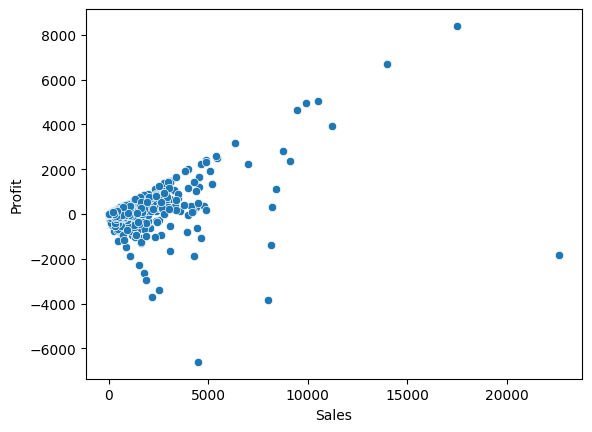

In [22]:
sns.scatterplot(
    x="Sales",
    y="Profit",
    data=df
)

##### Discount vs Profit

<Axes: xlabel='Discount', ylabel='Profit'>

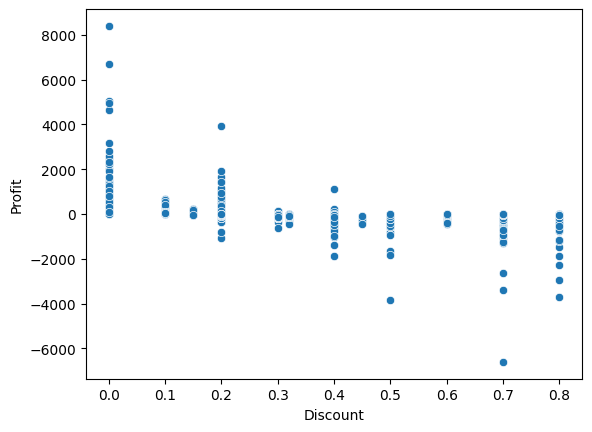

In [23]:
sns.scatterplot(
    x="Discount",
    y="Profit",
    data=df
)

Higher discounts appear to be associated with lower profit values.

###  7. Initial Insights

- Sales distribution is highly right-skewed.
- Profit includes both positive and negative values.
- Several numerical variables contain extreme values.
- Discount apperas negatively correlated with Profit.
- Consumer is the largest customer segment.
- Technology, Furniture and Office Supplies are the three major product categories.
- Temporal variables have been successfully created and are ready for further analysis.